# Sales Data Analysis
**Objective:** Analyze sales data to identify trends, seasonal effects, and the performance of different products.

**Dataset:** [Sample Sales Data](https://www.kaggle.com/datasets/kyanyoga/sample-sales-data) (Kaggle) — 2,823 orders, Jan 2003 – May 2005, 7 product lines, 19 countries.

**Tools:** Python (Pandas, Matplotlib, Seaborn)

## Step 0: Upload Your Data File

Run the cell below. If you're on **Google Colab**, an upload dialog will pop up immediately.
If you're on **local Jupyter/JupyterLab**, an upload button will appear — click it, choose your
CSV (e.g. `sales_data_sample.csv`), then run the next cell to finish loading it.

In [1]:
import os

DATA_FILENAME = None

# 1) Google Colab
try:
    from google.colab import files
    print("Please choose your sales data CSV file to upload...")
    _uploaded = files.upload()
    if _uploaded:
        DATA_FILENAME = list(_uploaded.keys())[0]
        with open(DATA_FILENAME, 'wb') as f:
            f.write(_uploaded[DATA_FILENAME])
        print(f"Uploaded: {DATA_FILENAME}")
except ImportError:
    pass

# 2) Local Jupyter/JupyterLab - show an upload widget
if DATA_FILENAME is None:
    try:
        import ipywidgets as widgets
        from IPython.display import display

        upload_widget = widgets.FileUpload(accept='.csv', multiple=False, description='Upload CSV')
        display(upload_widget)
        print("Click 'Upload CSV' above, select your file, then run the next cell.")
    except ImportError:
        print("ipywidgets not available. Place your CSV in this notebook's folder, "
              "then run the next cell (it will auto-detect it).")

FileUpload(value=(), accept='.csv', description='Upload CSV')

Click 'Upload CSV' above, select your file, then run the next cell.


In [2]:
# Run this AFTER uploading above (safe to run even if the Colab upload already worked)
if DATA_FILENAME is None:
    try:
        val = upload_widget.value
        if val:
            item = list(val.values())[0] if isinstance(val, dict) else val[0]
            DATA_FILENAME = item['metadata']['name'] if 'metadata' in item else item['name']
            content = item['content']
            with open(DATA_FILENAME, 'wb') as f:
                f.write(content.tobytes() if hasattr(content, 'tobytes') else content)
            print(f"Uploaded: {DATA_FILENAME}")
    except NameError:
        pass

if DATA_FILENAME is None:
    # Fall back to a CSV already sitting in this folder
    _csvs = [f for f in os.listdir('.') if f.lower().endswith('.csv')]
    if _csvs:
        DATA_FILENAME = _csvs[0]
        print(f"No upload detected - using existing file found in folder: {DATA_FILENAME}")
    else:
        DATA_FILENAME = input("No file uploaded and none found in folder. Enter the path to your CSV: ").strip()

print("Using data file:", DATA_FILENAME)

No upload detected - using existing file found in folder: sales_data_sample.csv
Using data file: sales_data_sample.csv


## Step 1: Load & Explore the Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(DATA_FILENAME, encoding='latin1')
print('Shape:', df.shape)
df.head()

Shape: (2823, 25)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
print('Dtypes:')
print(df.dtypes)
print()
print('Missing values (columns with any):')
print(df.isnull().sum()[df.isnull().sum() > 0])

Dtypes:
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object

Missing values (columns with any):
ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64


In [5]:
print('Product lines:', df['PRODUCTLINE'].unique())
print('Years:', sorted(df['YEAR_ID'].unique()))

Product lines: <StringArray>
[     'Motorcycles',     'Classic Cars', 'Trucks and Buses',
     'Vintage Cars',           'Planes',            'Ships',
           'Trains']
Length: 7, dtype: str
Years: [np.int64(2003), np.int64(2004), np.int64(2005)]


## Step 2: Clean the Data

- Convert `ORDERDATE` to a real datetime
- Drop PII / irrelevant columns (phone, address lines, contact names) — not needed for this analysis
- Add helper columns: `MONTH_NAME`, `YEAR_MONTH`

In [6]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

drop_cols = ['PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'POSTALCODE',
             'CONTACTLASTNAME', 'CONTACTFIRSTNAME']
df = df.drop(columns=drop_cols)

df['MONTH_NAME'] = df['ORDERDATE'].dt.month_name()
df['YEAR_MONTH'] = df['ORDERDATE'].dt.to_period('M').astype(str)

print('Cleaned shape:', df.shape)
print('True date range:', df['ORDERDATE'].min(), 'to', df['ORDERDATE'].max())
df[['ORDERDATE','SALES','PRODUCTLINE','QTR_ID','YEAR_ID','DEALSIZE']].head()

Cleaned shape: (2823, 21)
True date range: 2003-01-06 00:00:00 to 2005-05-31 00:00:00


,ORDERDATE,SALES,PRODUCTLINE,QTR_ID,YEAR_ID,DEALSIZE
0,2003-02-24,2871.00,Motorcycles,1,2003,Small
1,2003-05-07,2765.90,Motorcycles,2,2003,Small
2,2003-07-01,3884.34,Motorcycles,3,2003,Medium
3,2003-08-25,3746.70,Motorcycles,3,2003,Medium
4,2003-10-10,5205.27,Motorcycles,4,2003,Medium


In [7]:
# Note: 2005 only has data through May - it's a PARTIAL year.
# Keep this in mind when comparing years later.
df.groupby('YEAR_ID')['ORDERDATE'].agg(['min', 'max', 'count'])

,min,max,count
YEAR_ID,,,
2003,2003-01-06,2003-12-09,1000
2004,2004-01-02,2004-12-17,1345
2005,2005-01-05,2005-05-31,478


## Step 3: Sales Trends Over Time

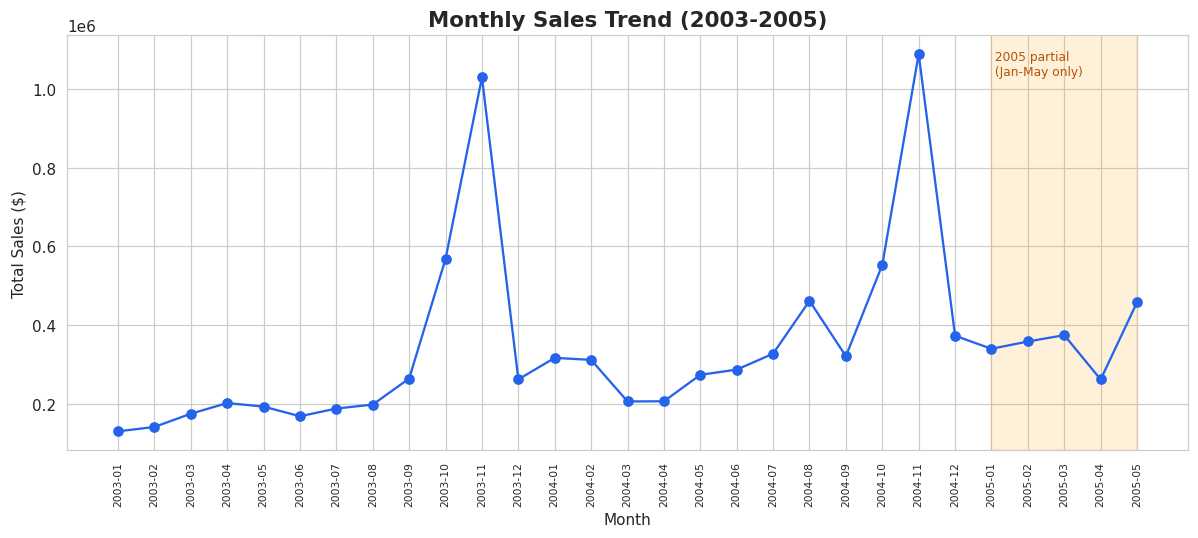

In [8]:
monthly = df.groupby('YEAR_MONTH')['SALES'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly['YEAR_MONTH'], monthly['SALES'], marker='o', color='#2563eb')
ax.set_title('Monthly Sales Trend (2003-2005)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=90, fontsize=7)
ax.axvspan(len(monthly)-5, len(monthly)-1, color='orange', alpha=0.15)
ax.text(len(monthly)-5, monthly['SALES'].max()*0.95, ' 2005 partial\n (Jan-May only)',
        fontsize=8, color='#b45309')
plt.tight_layout()
plt.show()

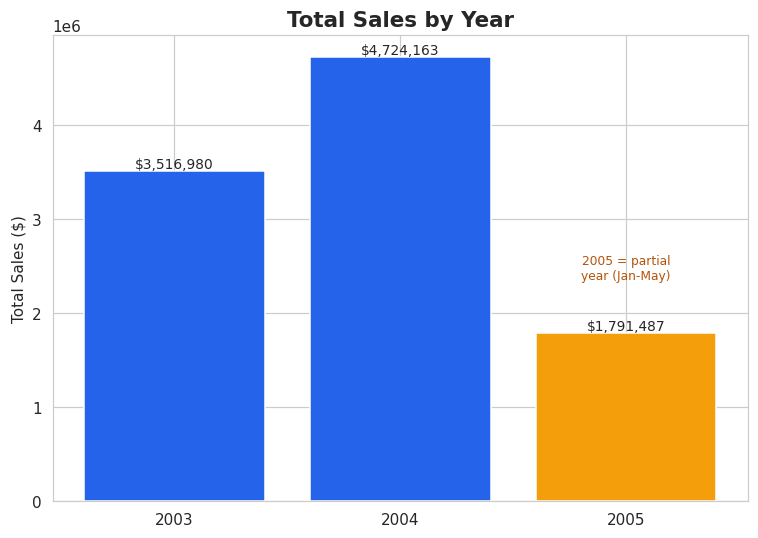

,YEAR_ID,SALES
0,2003,3516979.54
1,2004,4724162.60
2,2005,1791486.71


In [9]:
yearly = df.groupby('YEAR_ID')['SALES'].sum().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(yearly['YEAR_ID'].astype(str), yearly['SALES'], color=['#2563eb','#2563eb','#f59e0b'])
ax.set_title('Total Sales by Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'${b.get_height():,.0f}',
            ha='center', va='bottom', fontsize=9)
ax.text(2, yearly['SALES'].max()*0.5, '2005 = partial\nyear (Jan-May)',
        ha='center', fontsize=8, color='#b45309')
plt.tight_layout()
plt.show()

yearly

In [10]:
y2003 = df[df.YEAR_ID == 2003]['SALES'].sum()
y2004 = df[df.YEAR_ID == 2004]['SALES'].sum()
print(f'2003 total: ${y2003:,.2f}')
print(f'2004 total: ${y2004:,.2f}')
print(f'YoY growth 2003 -> 2004: {(y2004 - y2003) / y2003 * 100:.1f}%')

2003 total: $3,516,979.54
2004 total: $4,724,162.60
YoY growth 2003 -> 2004: 34.3%


## Step 4: Seasonal Effects

Using only full years (2003 + 2004) so the partial 2005 data doesn't skew the seasonal pattern.

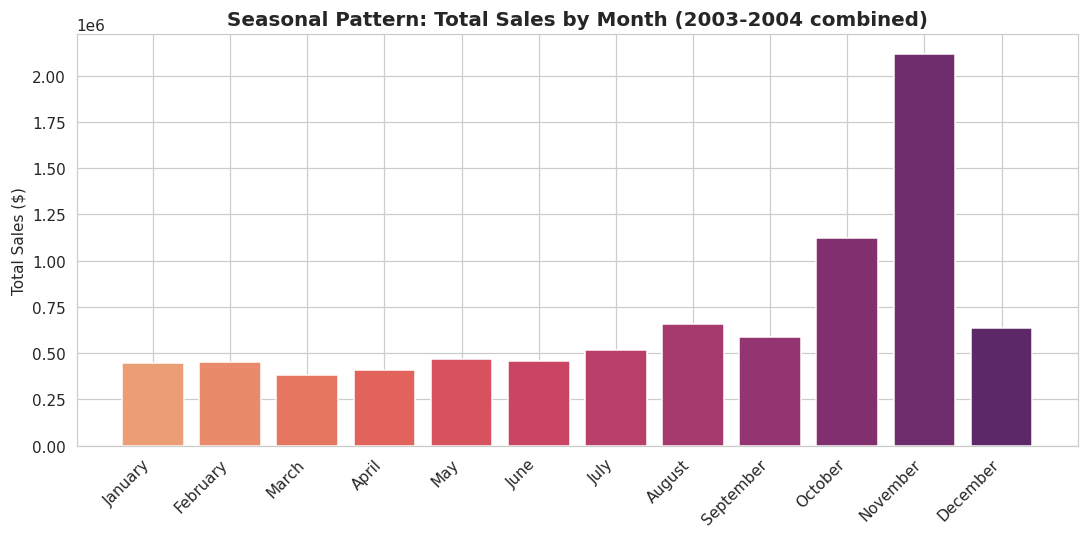

Top 3 months:
MONTH_NAME
November    2118885.67
October     1121215.22
August       659310.57
Name: SALES, dtype: float64

Bottom 3 months:
MONTH_NAME
January    446331.02
April      407757.67
March      380238.63
Name: SALES, dtype: float64


In [11]:
full_years = df[df['YEAR_ID'].isin([2003, 2004])]
seasonal = full_years.groupby('MONTH_NAME')['SALES'].sum().reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('flare', len(seasonal))
ax.bar(seasonal.index, seasonal.values, color=colors)
ax.set_title('Seasonal Pattern: Total Sales by Month (2003-2004 combined)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 3 months:'); print(seasonal.sort_values(ascending=False).head(3))
print()
print('Bottom 3 months:'); print(seasonal.sort_values(ascending=False).tail(3))

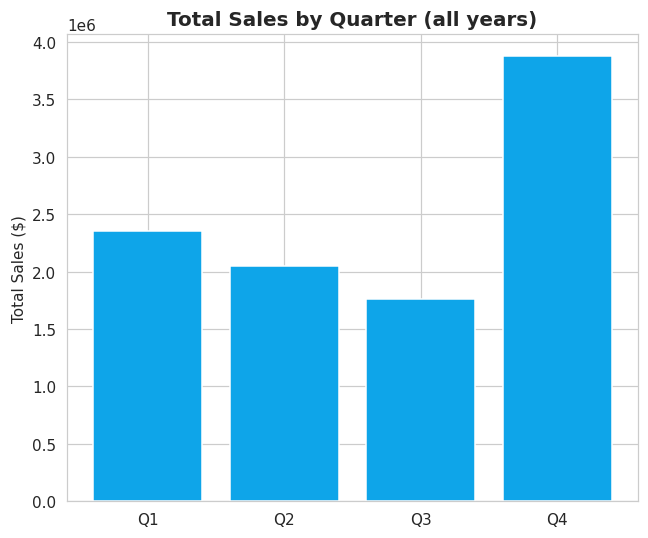

QTR_ID
1    2350817.73
2    2048120.30
3    1758910.81
4    3874780.01
Name: SALES, dtype: float64

In [12]:
qtr = df.groupby('QTR_ID')['SALES'].sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Q1','Q2','Q3','Q4'], qtr.values, color='#0ea5e9')
ax.set_title('Total Sales by Quarter (all years)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

qtr

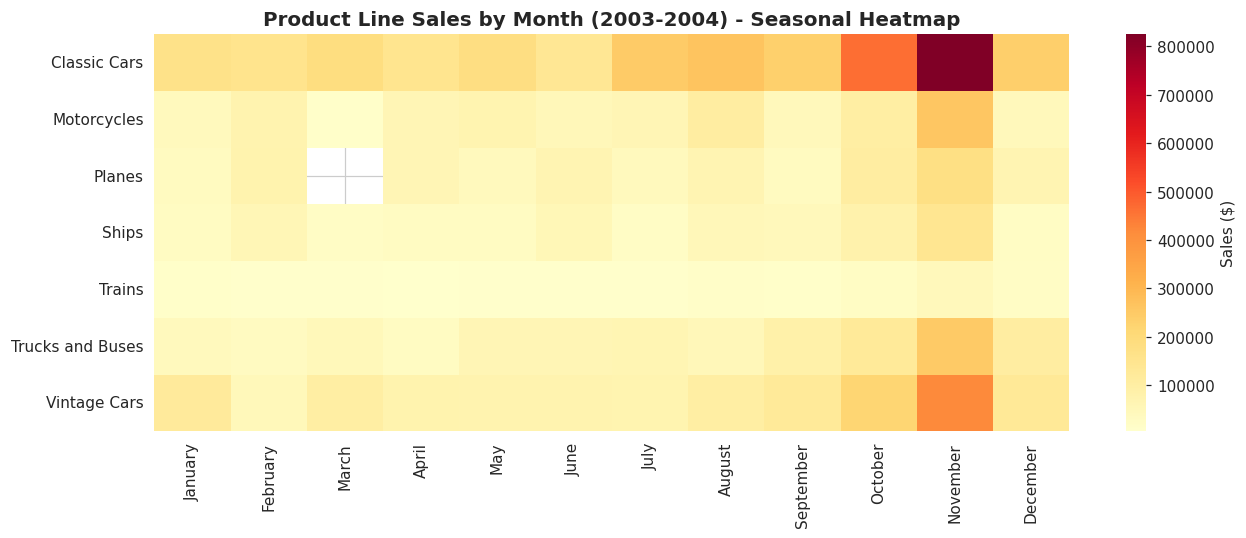

In [13]:
# Does the seasonal pattern hold across every product line, or is it driven by one?
heat_data = full_years.pivot_table(index='PRODUCTLINE', columns='MONTH_NAME',
                                    values='SALES', aggfunc='sum').reindex(columns=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_data, cmap='YlOrRd', annot=False, ax=ax, cbar_kws={'label': 'Sales ($)'})
ax.set_title('Product Line Sales by Month (2003-2004) - Seasonal Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Step 5: Product Performance

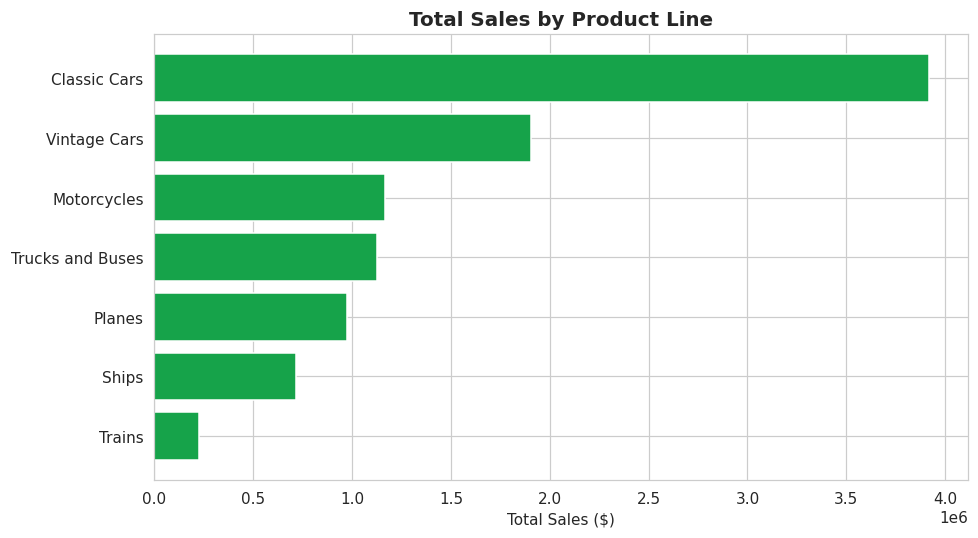

,Total_Sales,Orders,Avg_Sale
PRODUCTLINE,,,
Classic Cars,3919615.66,199,4053.377104
Vintage Cars,1903150.84,175,3135.339110
Motorcycles,1166388.34,72,3523.831843
Trucks and Buses,1127789.84,73,3746.810100
Planes,975003.57,59,3186.286176
Ships,714437.13,65,3053.150128
Trains,226243.47,45,2938.226883


In [14]:
prod = df.groupby('PRODUCTLINE').agg(
    Total_Sales=('SALES', 'sum'),
    Orders=('ORDERNUMBER', 'nunique'),
    Avg_Sale=('SALES', 'mean')
).sort_values('Total_Sales', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(prod.index[::-1], prod['Total_Sales'][::-1], color='#16a34a')
ax.set_title('Total Sales by Product Line', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

prod

## Step 6: Supporting Insights — Deal Size & Geography

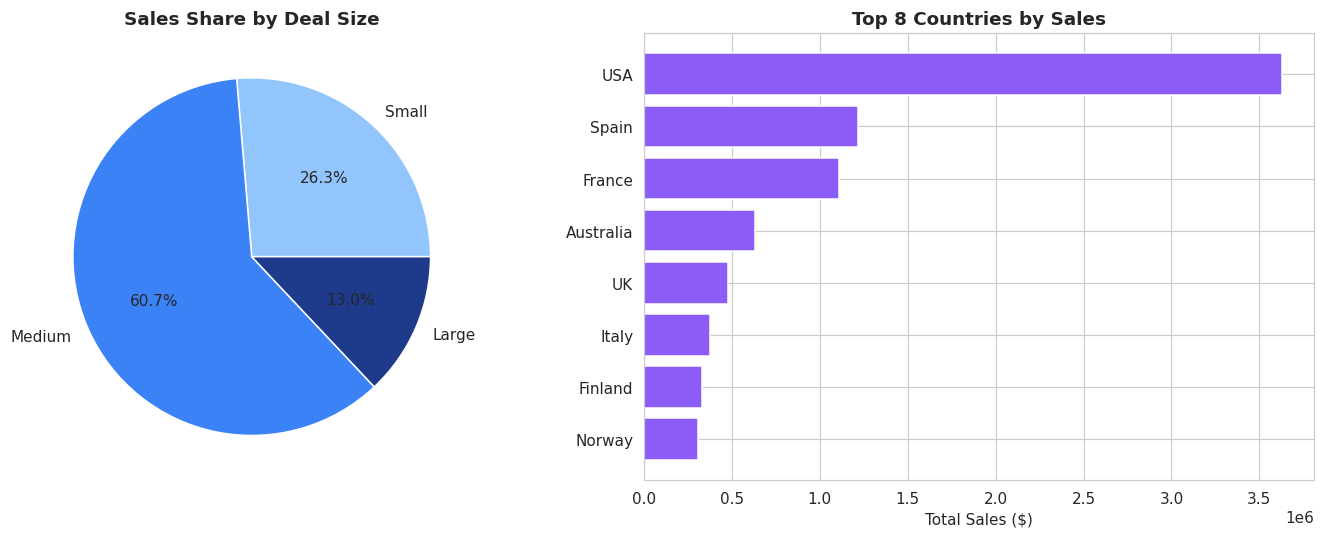

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

deal = df.groupby('DEALSIZE')['SALES'].sum().reindex(['Small','Medium','Large'])
axes[0].pie(deal.values, labels=deal.index, autopct='%1.1f%%', colors=['#93c5fd','#3b82f6','#1e3a8a'])
axes[0].set_title('Sales Share by Deal Size', fontweight='bold')

top_countries = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(8)
axes[1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#8b5cf6')
axes[1].set_title('Top 8 Countries by Sales', fontweight='bold')
axes[1].set_xlabel('Total Sales ($)')

plt.tight_layout()
plt.show()

## Step 7: Key Insights & Recommendations

**Trends**
- Total revenue across the dataset: **$10,032,628.85**
- Full-year growth: 2003 ($3.52M) → 2004 ($4.72M) = **+34.3% YoY**
- 2005 is a **partial year** (Jan–May only) — not a real decline, just incomplete data

**Seasonality**
- **November** is the peak month by far (~$2.12M combined 2003-2004), more than double any other month
- **Q4** is the strongest quarter overall — a clear holiday-driven buying pattern
- January–March are consistently the weakest months
- The seasonal spike holds across **almost every product line** (see heatmap) — it's a company-wide pattern, not one product driving it

**Product Performance**
- **Classic Cars** dominates with ~39% of total revenue — more than double the next-best line
- **Trains** is by far the weakest performer

**Recommendations**
1. Plan inventory/staffing for the Q4 (esp. Oct–Nov) demand surge
2. Prioritize Classic Cars in Q4 marketing given its scale and seasonal spike
3. Investigate why Trains underperforms so heavily — pricing, distribution, or demand issue
4. Consider early-year (Q1) promotions to smooth out the seasonal slump

In [16]:
print('=== TOP-LINE SUMMARY ===')
print(f"Total revenue: ${df['SALES'].sum():,.2f}")
print(f"Best month: {seasonal.idxmax()} (${seasonal.max():,.0f})")
print(f"Best quarter: Q{qtr.idxmax()} (${qtr.max():,.0f})")
print(f"Top product line: {prod.index[0]} (${prod['Total_Sales'].iloc[0]:,.0f})")
print(f"Bottom product line: {prod.index[-1]} (${prod['Total_Sales'].iloc[-1]:,.0f})")
print(f"Top country: {top_countries.index[0]} (${top_countries.iloc[0]:,.0f})")

=== TOP-LINE SUMMARY ===
Total revenue: $10,032,628.85
Best month: November ($2,118,886)
Best quarter: Q4 ($3,874,780)
Top product line: Classic Cars ($3,919,616)
Bottom product line: Trains ($226,243)
Top country: USA ($3,627,983)
